# Goal:
- Load processed multimodal sensor features
- Keep 3-class labels: rest / moderate / intense
- Run strict leave-one-file-out evaluation
- Compare QSVM vs Random Forest vs classical SVM
- Explore preprocessing techniques
- Explore encoding techniques
- Explore entanglement techniques
- Optimize QSVM circuit depth
- Save metrics and charts for reporting

## 1) Imports

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings

from pathlib import Path

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, Normalizer
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

## 2) Qiskit imports

In [10]:
from qiskit_machine_learning.algorithms import QSVC
from qiskit_machine_learning.kernels import FidelityQuantumKernel

try:
    from qiskit.circuit.library import ZZFeatureMap, ZFeatureMap, PauliFeatureMap
except Exception as e:
    print("Qiskit import issue:", e)

## 3) Paths

In [11]:
DATA_PATH = Path("../data/processed/activity_fusion_features_sensors_strict.csv")

OUTPUT_DIR = Path("../data/processed")
PLOTS_DIR = Path("../outputs/plots")
LOGS_DIR = Path("../outputs/logs")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
LOGS_DIR.mkdir(parents=True, exist_ok=True)

print("Loading from:", DATA_PATH.resolve())

Loading from: C:\Users\vPro\OneDrive - Al Akhawayn University in Ifrane\AUI\capstone\capstone\ml_pipeline\data\processed\activity_fusion_features_sensors_strict.csv


## 4) Load dataset

In [13]:
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print(df.columns.tolist())
df.head()

Shape: (391, 45)
['hr_mean', 'hr_std', 'hr_min', 'hr_max', 'hr_range', 'temp_mean', 'temp_std', 'temp_min', 'temp_max', 'temp_slope', 'emg_raw_mean', 'emg_raw_std', 'emg_env_mean', 'emg_env_std', 'emg_rms', 'emg_mav', 'emg_wl', 'emg_zero_cross', 'emg_state_mean', 'ax_mean', 'ax_std', 'ax_min', 'ax_max', 'ay_mean', 'ay_std', 'ay_min', 'ay_max', 'az_mean', 'az_std', 'az_min', 'az_max', 'acc_mag_mean', 'acc_mag_std', 'acc_mag_min', 'acc_mag_max', 'acc_mag_range', 'acc_mag_energy', 'jerk_mean', 'jerk_std', 'label_name', 'label', 'source_file', 'window_start', 'window_end', 'n_samples']


,hr_mean,hr_std,hr_min,hr_max,hr_range,temp_mean,temp_std,temp_min,temp_max,temp_slope,...,acc_mag_range,acc_mag_energy,jerk_mean,jerk_std,label_name,label,source_file,window_start,window_end,n_samples
0,97.300000,2.213594,94.0,101.0,7.0,27.723000,0.102746,27.56,27.87,-0.031000,...,2041.468517,3.373528e+08,614.065686,866.594422,intense,2,intense/intense_running_20260414_195242.csv,2026-04-14 19:53:17.519406,2026-04-14 19:53:27.519406,10
1,105.900000,2.998148,101.0,109.0,8.0,27.275000,0.224314,26.94,27.56,-0.062000,...,17747.568929,3.820010e+08,11053.029205,11543.581328,intense,2,intense/intense_running_20260414_195242.csv,2026-04-14 19:53:27.519406,2026-04-14 19:53:37.519406,10
2,107.888889,3.551213,105.0,114.0,9.0,26.582222,0.195114,26.31,26.87,-0.062222,...,21984.351951,5.460429e+08,13962.586061,14692.866503,intense,2,intense/intense_running_20260414_195242.csv,2026-04-14 19:53:37.519406,2026-04-14 19:53:47.519406,9
3,122.300000,5.375872,114.0,129.0,15.0,25.968000,0.189021,25.69,26.25,-0.056000,...,18848.170897,4.017341e+08,13013.301236,13811.219595,intense,2,intense/intense_running_20260414_195242.csv,2026-04-14 19:53:47.519406,2026-04-14 19:53:57.519406,10
4,126.900000,0.994429,126.0,129.0,3.0,25.461000,0.139400,25.25,25.69,-0.044000,...,21599.531893,4.433055e+08,11563.092523,13163.102565,intense,2,intense/intense_running_20260414_195242.csv,2026-04-14 19:53:57.519406,2026-04-14 19:54:07.519406,10


## 5) Check class distribution

In [14]:
LABEL_NAMES = {
    0: "rest",
    1: "moderate",
    2: "intense"
}

print(df["label"].value_counts())
print(df["label"].map(LABEL_NAMES).value_counts())

print("\nFiles:")
print(df["source_file"].value_counts())

label
1    148
2    123
0    120
Name: count, dtype: int64
label
moderate    148
intense     123
rest        120
Name: count, dtype: int64

Files:
source_file
intense/intense_running_20260414_195242.csv      36
moderate/moderate_walking_20260417_150822.csv    36
moderate/moderate_walking_20260417_151525.csv    36
moderate/moderate_walking_20260407_120447.csv    33
intense/intense_running_20260417_162157.csv      31
rest/rest_20260417_152340.csv                    31
rest/rest_20260417_152938.csv                    30
rest/rest_20260419_212846.csv                    30
rest/rest_20260419_212016.csv                    29
intense/intense_running_20260417_160438.csv      28
moderate/moderate_stairs_20260417_163918.csv     18
moderate/moderate_stairs_20260417_164326.csv     13
moderate/moderate_stairs_20260411_224148.csv     12
intense/intense_squats_20260417_154922.csv       10
intense/intense_squats_20260411_223205.csv        9
intense/intense_squats_20260417_153856.csv        9
Name: cou

## 6) Select feature columns

In [15]:
# Keep only numeric sensor-derived features
exclude_cols = ["label", "source_file"]

feature_cols = [
    col for col in df.columns
    if col not in exclude_cols and pd.api.types.is_numeric_dtype(df[col])
]

print("Selected features:")
print(feature_cols)
print("Number of features:", len(feature_cols))

Selected features:
['hr_mean', 'hr_std', 'hr_min', 'hr_max', 'hr_range', 'temp_mean', 'temp_std', 'temp_min', 'temp_max', 'temp_slope', 'emg_raw_mean', 'emg_raw_std', 'emg_env_mean', 'emg_env_std', 'emg_rms', 'emg_mav', 'emg_wl', 'emg_zero_cross', 'emg_state_mean', 'ax_mean', 'ax_std', 'ax_min', 'ax_max', 'ay_mean', 'ay_std', 'ay_min', 'ay_max', 'az_mean', 'az_std', 'az_min', 'az_max', 'acc_mag_mean', 'acc_mag_std', 'acc_mag_min', 'acc_mag_max', 'acc_mag_range', 'acc_mag_energy', 'jerk_mean', 'jerk_std', 'n_samples']
Number of features: 40


## 6b) Minimize features

In [16]:
selected_features = [
    "hr_mean",
    "temp_mean",
    "emg_rms",
    "acc_mag_mean"
]

missing = [c for c in selected_features if c not in df.columns]
print("Missing features:", missing)

Missing features: []


## 7) Clean dataset

In [17]:
df = df.copy()

df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)
df[feature_cols] = df[feature_cols].fillna(df[feature_cols].median(numeric_only=True))

print("Missing values:")
print(df[feature_cols].isna().sum())

Missing values:
hr_mean           0
hr_std            0
hr_min            0
hr_max            0
hr_range          0
temp_mean         0
temp_std          0
temp_min          0
temp_max          0
temp_slope        0
emg_raw_mean      0
emg_raw_std       0
emg_env_mean      0
emg_env_std       0
emg_rms           0
emg_mav           0
emg_wl            0
emg_zero_cross    0
emg_state_mean    0
ax_mean           0
ax_std            0
ax_min            0
ax_max            0
ay_mean           0
ay_std            0
ay_min            0
ay_max            0
az_mean           0
az_std            0
az_min            0
az_max            0
acc_mag_mean      0
acc_mag_std       0
acc_mag_min       0
acc_mag_max       0
acc_mag_range     0
acc_mag_energy    0
jerk_mean         0
jerk_std          0
n_samples         0
dtype: int64


## 8) Sample per file to keep QSVM manageable

In [18]:
# QSVM is slow because it computes a quantum kernel matrix.
# So we use a small balanced sample from each recording file.

MAX_WINDOWS_PER_FILE = 8

sampled_parts = []

for file_name in df["source_file"].unique():
    part = df[df["source_file"] == file_name].copy()
    part = part.sample(n=min(len(part), MAX_WINDOWS_PER_FILE), random_state=RANDOM_STATE)
    sampled_parts.append(part)

df_qsvm = pd.concat(sampled_parts, axis=0).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print("Sampled QSVM shape:", df_qsvm.shape)
print(df_qsvm["label"].value_counts())
print(df_qsvm["source_file"].value_counts())

Sampled QSVM shape: (128, 45)
label
1    48
2    48
0    32
Name: count, dtype: int64
source_file
moderate/moderate_stairs_20260411_224148.csv     8
intense/intense_squats_20260417_154922.csv       8
intense/intense_running_20260417_162157.csv      8
intense/intense_squats_20260411_223205.csv       8
rest/rest_20260417_152340.csv                    8
moderate/moderate_stairs_20260417_163918.csv     8
moderate/moderate_stairs_20260417_164326.csv     8
rest/rest_20260417_152938.csv                    8
moderate/moderate_walking_20260417_150822.csv    8
moderate/moderate_walking_20260417_151525.csv    8
intense/intense_running_20260414_195242.csv      8
rest/rest_20260419_212016.csv                    8
intense/intense_squats_20260417_153856.csv       8
rest/rest_20260419_212846.csv                    8
intense/intense_running_20260417_160438.csv      8
moderate/moderate_walking_20260407_120447.csv    8
Name: count, dtype: int64


## 9) Prepare X, y, groups

In [19]:
X_all = df_qsvm[feature_cols].copy()
y_all = df_qsvm["label"].astype(int).copy()
groups = df_qsvm["source_file"].copy()

unique_files = groups.unique()

print("X shape:", X_all.shape)
print("y shape:", y_all.shape)
print("Number of files:", len(unique_files))

X shape: (128, 40)
y shape: (128,)
Number of files: 16


## 10) Preprocessing techniques to compare

In [20]:
scalers = {
    "standard": StandardScaler(),
    "minmax": MinMaxScaler(feature_range=(-np.pi, np.pi)),
    "robust": RobustScaler(),
    "normalizer": Normalizer()
}

reducers = {
    "pca_2": PCA(n_components=2, random_state=RANDOM_STATE),
    "pca_3": PCA(n_components=3, random_state=RANDOM_STATE),
    "pca_4": PCA(n_components=4, random_state=RANDOM_STATE),
    "select_2": SelectKBest(mutual_info_classif, k=2),
    "select_3": SelectKBest(mutual_info_classif, k=3),
    "select_4": SelectKBest(mutual_info_classif, k=4),
    "benchmark_4": "manual"
}

## 11) Helper function for preprocessing

In [21]:
def preprocess_data(X_train, X_test, y_train, scaler_name, reducer_name):

    # Scaling options
    if scaler_name == "dual_standard_minmax":
        std_scaler = StandardScaler()
        X_train_scaled = std_scaler.fit_transform(X_train)
        X_test_scaled = std_scaler.transform(X_test)

        minmax_scaler = MinMaxScaler(feature_range=(0, np.pi))
        X_train_scaled = minmax_scaler.fit_transform(X_train_scaled)
        X_test_scaled = minmax_scaler.transform(X_test_scaled)

    elif scaler_name == "robust_minmax":
        robust_scaler = RobustScaler()
        X_train_scaled = robust_scaler.fit_transform(X_train)
        X_test_scaled = robust_scaler.transform(X_test)

        minmax_scaler = MinMaxScaler(feature_range=(0, np.pi))
        X_train_scaled = minmax_scaler.fit_transform(X_train_scaled)
        X_test_scaled = minmax_scaler.transform(X_test_scaled)

    else:
        scaler = scalers[scaler_name]
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

    # Feature reduction options
    if reducer_name == "benchmark_4":
        selected_cols = selected_features
        selected_idx = [feature_cols.index(col) for col in selected_cols]

        X_train_reduced = X_train_scaled[:, selected_idx]
        X_test_reduced = X_test_scaled[:, selected_idx]

    else:
        reducer = reducers[reducer_name]
        X_train_reduced = reducer.fit_transform(X_train_scaled, y_train)
        X_test_reduced = reducer.transform(X_test_scaled)

    # Keep values in safe quantum angle range
    X_train_reduced = np.clip(X_train_reduced, 0, np.pi)
    X_test_reduced = np.clip(X_test_reduced, 0, np.pi)

    return X_train_reduced, X_test_reduced

## 12) Encoding and entanglement techniques

In [22]:
def build_feature_map(encoding, num_features, reps=1, entanglement="linear"):
    
    if encoding == "z":
        return ZFeatureMap(
            feature_dimension=num_features,
            reps=reps
        )

    elif encoding == "zz":
        return ZZFeatureMap(
            feature_dimension=num_features,
            reps=reps,
            entanglement=entanglement
        )

    elif encoding == "pauli_z":
        return PauliFeatureMap(
            feature_dimension=num_features,
            reps=reps,
            paulis=["Z"],
            entanglement=entanglement
        )

    elif encoding == "pauli_zz":
        return PauliFeatureMap(
            feature_dimension=num_features,
            reps=reps,
            paulis=["Z", "ZZ"],
            entanglement=entanglement
        )

    else:
        raise ValueError("Unknown encoding type")

## 13) Define QSVM optimization search space

In [23]:
qsvm_configs = []

for scaler_name in ["standard", "minmax"]:
    for reducer_name in ["pca_3", "pca_4"]:
        for encoding in ["zz", "pauli_zz"]:
            for entanglement in ["linear", "circular"]:
                for reps in [1]:
                    qsvm_configs.append({
                        "scaler": scaler_name,
                        "reducer": reducer_name,
                        "encoding": encoding,
                        "entanglement": entanglement,
                        "reps": reps
                    })

print("Total QSVM configurations:", len(qsvm_configs))

Total QSVM configurations: 16


Note: Due to the high computational cost of Quantum Support Vector Machine training on classical simulators, an exhaustive search across all possible preprocessing, encoding, entanglement, and circuit configurations was not practical. Therefore, a targeted experimental design was adopted using a reduced set of representative techniques chosen for both relevance and feasibility. For preprocessing, StandardScaler and MinMaxScaler were selected because StandardScaler is a strong classical baseline, while MinMaxScaler is particularly suitable for quantum feature maps since it bounds values used in rotation gates. For dimensionality reduction, PCA with 3 and 4 components was used to preserve most of the signal variance while limiting the number of qubits and reducing circuit complexity. For data encoding, ZZFeatureMap and PauliFeatureMap with Z and ZZ terms were selected because they are widely used kernel-based encodings that model both individual features and pairwise interactions. For entanglement, linear and circular topologies were chosen to compare a lightweight nearest-neighbor structure against a more connected architecture with moderate additional cost. Finally, shallow circuit depths were prioritized to maintain reasonable execution times and avoid unnecessary simulator overhead. This reduced search space allowed a meaningful comparison of the most influential QSVM design choices while keeping the experiments computationally realistic.


## 13b) Alternative QSVM optimization search space

In [24]:
alternative_qsvm_configs = []

for scaler_name in ["dual_standard_minmax", "robust_minmax"]:
    for encoding in ["zz", "pauli_zz"]:
        for entanglement in ["linear", "circular", "full"]:
            alternative_qsvm_configs.append({
                "scaler": scaler_name,
                "reducer": "benchmark_4",
                "encoding": encoding,
                "entanglement": entanglement,
                "reps": 1,
                "search_phase": "benchmark_features_dual_scaling"
            })

print("Total alternative QSVM configurations:", len(alternative_qsvm_configs))

Total alternative QSVM configurations: 12


Note: During the optimization phase, an initial set of QSVM configurations using single-scaler preprocessing and PCA-based dimensionality reduction produced weak results. This indicated that variance-based compression was not preserving the most discriminative wearable sensor features. Therefore, a second targeted optimization phase was introduced using the four manually selected benchmark features that had previously shown stronger performance. In this alternative phase, dual preprocessing pipelines were added, combining StandardScaler followed by MinMax scaling, as well as RobustScaler followed by MinMax scaling, to improve quantum angle encoding while handling feature distribution differences and potential sensor outliers. These revised configurations significantly improved QSVM performance, demonstrating that quantum models were highly sensitive to preprocessing design and that preserving meaningful handcrafted features was more effective than PCA for this dataset.


## 14) Strict Leave-One-File-Out QSVM evaluation function

In [25]:
def evaluate_qsvm_config(config):
    
    all_true = []
    all_preds = []
    file_results = []

    start_total = time.time()

    for test_file in unique_files:

        train_idx = groups != test_file
        test_idx = groups == test_file

        X_train = X_all[train_idx].copy()
        X_test = X_all[test_idx].copy()
        y_train = y_all[train_idx].copy()
        y_test = y_all[test_idx].copy()

        if len(np.unique(y_train)) < 3:
            continue

        try:
            X_train_p, X_test_p = preprocess_data(
                X_train,
                X_test,
                y_train,
                scaler_name=config["scaler"],
                reducer_name=config["reducer"]
            )

            num_features = X_train_p.shape[1]

            feature_map = build_feature_map(
                encoding=config["encoding"],
                num_features=num_features,
                reps=config["reps"],
                entanglement=config["entanglement"]
            )

            quantum_kernel = FidelityQuantumKernel(feature_map=feature_map)
            qsvc = QSVC(quantum_kernel=quantum_kernel)

            fold_start = time.time()

            qsvc.fit(X_train_p, y_train)
            y_pred = qsvc.predict(X_test_p)

            fold_time = time.time() - fold_start

            acc = accuracy_score(y_test, y_pred)

            file_results.append({
                "test_file": test_file,
                "n_test_windows": len(y_test),
                "accuracy": acc,
                "time_sec": fold_time
            })

            all_true.extend(y_test)
            all_preds.extend(y_pred)

        except Exception as e:
            print("Failed config:", config)
            print("Error:", e)
            return None, None

    total_time = time.time() - start_total

    if len(all_true) == 0:
        return None, None

    summary = {
        "model": "QSVM",
        "scaler": config["scaler"],
        "reducer": config["reducer"],
        "encoding": config["encoding"],
        "entanglement": config["entanglement"],
        "reps": config["reps"],
        "accuracy": accuracy_score(all_true, all_preds),
        "precision": precision_score(all_true, all_preds, average="macro", zero_division=0),
        "recall": recall_score(all_true, all_preds, average="macro", zero_division=0),
        "f1": f1_score(all_true, all_preds, average="macro", zero_division=0),
        "time_sec": total_time
    }

    return summary, pd.DataFrame(file_results)

## 15) Run QSVM optimization

In [22]:
qsvm_summaries = []
qsvm_file_results_dict = {}

for i, config in enumerate(qsvm_configs):
    print(f"\nRunning QSVM config {i+1}/{len(qsvm_configs)}")
    print(config)

    summary, file_results = evaluate_qsvm_config(config)

    if summary is not None:
        qsvm_summaries.append(summary)

        config_name = (
            f"{config['scaler']}_"
            f"{config['reducer']}_"
            f"{config['encoding']}_"
            f"{config['entanglement']}_"
            f"reps{config['reps']}"
        )

        qsvm_file_results_dict[config_name] = file_results

        print("Accuracy:", round(summary["accuracy"], 4))
        print("F1:", round(summary["f1"], 4))
        print("Time:", round(summary["time_sec"], 2), "sec")


Running QSVM config 1/16
{'scaler': 'standard', 'reducer': 'pca_3', 'encoding': 'zz', 'entanglement': 'linear', 'reps': 1}
Accuracy: 0.3281
F1: 0.3166
Time: 599.96 sec

Running QSVM config 2/16
{'scaler': 'standard', 'reducer': 'pca_3', 'encoding': 'zz', 'entanglement': 'circular', 'reps': 1}
Accuracy: 0.4531
F1: 0.4537
Time: 683.06 sec

Running QSVM config 3/16
{'scaler': 'standard', 'reducer': 'pca_3', 'encoding': 'pauli_zz', 'entanglement': 'linear', 'reps': 1}
Accuracy: 0.3281
F1: 0.3166
Time: 646.4 sec

Running QSVM config 4/16
{'scaler': 'standard', 'reducer': 'pca_3', 'encoding': 'pauli_zz', 'entanglement': 'circular', 'reps': 1}
Accuracy: 0.4531
F1: 0.4537
Time: 674.75 sec

Running QSVM config 5/16
{'scaler': 'standard', 'reducer': 'pca_4', 'encoding': 'zz', 'entanglement': 'linear', 'reps': 1}
Accuracy: 0.3359
F1: 0.3228
Time: 845.54 sec

Running QSVM config 6/16
{'scaler': 'standard', 'reducer': 'pca_4', 'encoding': 'zz', 'entanglement': 'circular', 'reps': 1}
Accuracy: 0.35

## 15b) Run alternative QSVM optimization

In [35]:
alternative_qsvm_summaries = []
alternative_qsvm_file_results_dict = {}

for i, config in enumerate(alternative_qsvm_configs):
    print(f"\nRunning alternative QSVM config {i+1}/{len(alternative_qsvm_configs)}")
    print(config)

    summary, file_results = evaluate_qsvm_config(config)

    if summary is not None:
        summary["search_phase"] = "alternative"
        alternative_qsvm_summaries.append(summary)

        config_name = (
            f"alternative_"
            f"{config['scaler']}_"
            f"{config['reducer']}_"
            f"{config['encoding']}_"
            f"{config['entanglement']}_"
            f"reps{config['reps']}"
        )

        alternative_qsvm_file_results_dict[config_name] = file_results

        print("Accuracy:", round(summary["accuracy"], 4))
        print("F1:", round(summary["f1"], 4))
        print("Time:", round(summary["time_sec"], 2), "sec")


Running alternative QSVM config 1/12
{'scaler': 'dual_standard_minmax', 'reducer': 'benchmark_4', 'encoding': 'zz', 'entanglement': 'linear', 'reps': 1, 'search_phase': 'benchmark_features_dual_scaling'}
Accuracy: 0.7422
F1: 0.759
Time: 1012.42 sec

Running alternative QSVM config 2/12
{'scaler': 'dual_standard_minmax', 'reducer': 'benchmark_4', 'encoding': 'zz', 'entanglement': 'circular', 'reps': 1, 'search_phase': 'benchmark_features_dual_scaling'}
Accuracy: 0.7266
F1: 0.7465
Time: 691.84 sec

Running alternative QSVM config 3/12
{'scaler': 'dual_standard_minmax', 'reducer': 'benchmark_4', 'encoding': 'zz', 'entanglement': 'full', 'reps': 1, 'search_phase': 'benchmark_features_dual_scaling'}
Accuracy: 0.6875
F1: 0.7133
Time: 786.75 sec

Running alternative QSVM config 4/12
{'scaler': 'dual_standard_minmax', 'reducer': 'benchmark_4', 'encoding': 'pauli_zz', 'entanglement': 'linear', 'reps': 1, 'search_phase': 'benchmark_features_dual_scaling'}
Accuracy: 0.7422
F1: 0.759
Time: 671.1 

Justification: Since wearable signals may contain outliers from EMG bursts, motion spikes, or unstable sensor contact, RobustScaler was tested as an alternative preprocessing step. In both cases, features were finally mapped to [0,π] to match the rotation-angle requirements of the quantum feature map. This allowed comparison between standard benchmark scaling and outlier-resistant scaling while keeping the quantum circuit size fixed to four selected features.

## 16) Combine core and alternative QSVM optimization results

In [26]:
import pandas as pd

qsvm_results_df = pd.read_csv("../data/processed/qsvm_optimization_results.csv")

qsvm_results_df = qsvm_results_df.sort_values(
    by=["accuracy", "f1", "time_sec"],
    ascending=[False, False, True]
).reset_index(drop=True)

qsvm_results_df.head(20)

,model,scaler,reducer,encoding,entanglement,reps,accuracy,precision,recall,f1,time_sec,search_phase
0,QSVM,robust_minmax,benchmark_4,pauli_zz,linear,1,0.742188,0.754866,0.763889,0.759000,636.498357,alternative
1,QSVM,robust_minmax,benchmark_4,zz,linear,1,0.742188,0.754866,0.763889,0.759000,647.371471,alternative
2,QSVM,dual_standard_minmax,benchmark_4,pauli_zz,linear,1,0.742188,0.754866,0.763889,0.759000,671.099133,alternative
3,QSVM,dual_standard_minmax,benchmark_4,zz,linear,1,0.742188,0.754866,0.763889,0.759000,1012.416992,alternative
4,QSVM,robust_minmax,benchmark_4,pauli_zz,circular,1,0.726562,0.755198,0.739583,0.746471,670.068681,alternative
5,QSVM,robust_minmax,benchmark_4,zz,circular,1,0.726562,0.755198,0.739583,0.746471,675.981159,alternative
6,QSVM,dual_standard_minmax,benchmark_4,zz,circular,1,0.726562,0.755198,0.739583,0.746471,691.842383,alternative
7,QSVM,dual_standard_minmax,benchmark_4,pauli_zz,circular,1,0.726562,0.755198,0.739583,0.746471,807.380706,alternative
8,QSVM,robust_minmax,benchmark_4,zz,full,1,0.687500,0.730007,0.701389,0.713286,744.154531,alternative
9,QSVM,robust_minmax,benchmark_4,pauli_zz,full,1,0.687500,0.730007,0.701389,0.713286,758.198763,alternative


In [28]:
# Use combined results for all later notebook cells
print("Total tested configurations:", len(qsvm_results_df))
qsvm_results_df.head(10)

Total tested configurations: 28


,model,scaler,reducer,encoding,entanglement,reps,accuracy,precision,recall,f1,time_sec,search_phase
0,QSVM,robust_minmax,benchmark_4,pauli_zz,linear,1,0.742188,0.754866,0.763889,0.759000,636.498357,alternative
1,QSVM,robust_minmax,benchmark_4,zz,linear,1,0.742188,0.754866,0.763889,0.759000,647.371471,alternative
2,QSVM,dual_standard_minmax,benchmark_4,pauli_zz,linear,1,0.742188,0.754866,0.763889,0.759000,671.099133,alternative
3,QSVM,dual_standard_minmax,benchmark_4,zz,linear,1,0.742188,0.754866,0.763889,0.759000,1012.416992,alternative
4,QSVM,robust_minmax,benchmark_4,pauli_zz,circular,1,0.726562,0.755198,0.739583,0.746471,670.068681,alternative
5,QSVM,robust_minmax,benchmark_4,zz,circular,1,0.726562,0.755198,0.739583,0.746471,675.981159,alternative
6,QSVM,dual_standard_minmax,benchmark_4,zz,circular,1,0.726562,0.755198,0.739583,0.746471,691.842383,alternative
7,QSVM,dual_standard_minmax,benchmark_4,pauli_zz,circular,1,0.726562,0.755198,0.739583,0.746471,807.380706,alternative
8,QSVM,robust_minmax,benchmark_4,zz,full,1,0.687500,0.730007,0.701389,0.713286,744.154531,alternative
9,QSVM,robust_minmax,benchmark_4,pauli_zz,full,1,0.687500,0.730007,0.701389,0.713286,758.198763,alternative


## 17) Save QSVM optimization results

In [29]:
qsvm_results_path = OUTPUT_DIR / "qsvm_optimization_results.csv"
qsvm_results_df.to_csv(qsvm_results_path, index=False)

print("Saved:", qsvm_results_path)

Saved: ..\data\processed\qsvm_optimization_results.csv


## 18) Best QSVM configuration

In [30]:
best_qsvm = qsvm_results_df.iloc[0]

print("Best QSVM configuration:")
print(best_qsvm)

Best QSVM configuration:
model                    QSVM
scaler          robust_minmax
reducer           benchmark_4
encoding             pauli_zz
entanglement           linear
reps                        1
accuracy             0.742188
precision            0.754866
recall               0.763889
f1                      0.759
time_sec           636.498357
search_phase      alternative
Name: 0, dtype: object


# Visualize best QSVM quantum circuit

In [72]:
best_feature_map = build_feature_map(
    encoding=best_config["encoding"],
    num_features=len(selected_features),
    reps=best_config["reps"],
    entanglement=best_config["entanglement"]
)

best_feature_map.decompose().draw("mpl")
fig = best_feature_map.decompose().draw("mpl")
fig.savefig(PLOTS_DIR / "best_qsvm_quantum_circuit.png", dpi=300, bbox_inches="tight")

## 19) Re-run best QSVM and save detailed file-by-file results

In [48]:
# Final Best QSVM Evaluation 

best_qsvm = qsvm_results_df.iloc[0]

best_config = {
    "scaler": best_qsvm["scaler"],
    "reducer": best_qsvm["reducer"],
    "encoding": best_qsvm["encoding"],
    "entanglement": best_qsvm["entanglement"],
    "reps": int(best_qsvm["reps"])
}

pd.DataFrame([best_config]).to_csv(
    "../data/processed/best_qsvm_config.csv",
    index=False
)

def evaluate_best_qsvm_with_predictions(config):
    
    all_true = []
    all_preds = []
    file_results = []
    prediction_rows = []

    start_total = time.time()

    for test_file in unique_files:

        train_idx = groups != test_file
        test_idx = groups == test_file

        X_train = X_all[train_idx].copy()
        X_test = X_all[test_idx].copy()
        y_train = y_all[train_idx].copy()
        y_test = y_all[test_idx].copy()

        if len(np.unique(y_train)) < 3:
            continue

        X_train_p, X_test_p = preprocess_data(
            X_train,
            X_test,
            y_train,
            scaler_name=config["scaler"],
            reducer_name=config["reducer"]
        )

        feature_map = build_feature_map(
            encoding=config["encoding"],
            num_features=X_train_p.shape[1],
            reps=config["reps"],
            entanglement=config["entanglement"]
        )

        quantum_kernel = FidelityQuantumKernel(feature_map=feature_map)
        qsvc = QSVC(quantum_kernel=quantum_kernel)

        fold_start = time.time()
        qsvc.fit(X_train_p, y_train)
        y_pred = qsvc.predict(X_test_p)
        fold_time = time.time() - fold_start

        acc = accuracy_score(y_test, y_pred)

        file_results.append({
            "test_file": test_file,
            "n_test_windows": len(y_test),
            "accuracy": acc,
            "time_sec": fold_time
        })

        all_true.extend(y_test.tolist())
        all_preds.extend(y_pred.tolist())

        for true_label, pred_label in zip(y_test.tolist(), y_pred.tolist()):
            prediction_rows.append({
                "test_file": test_file,
                "y_true": true_label,
                "y_pred": pred_label
            })

    total_time = time.time() - start_total

    summary = {
        "model": "Optimized QSVM",
        "scaler": config["scaler"],
        "reducer": config["reducer"],
        "encoding": config["encoding"],
        "entanglement": config["entanglement"],
        "reps": config["reps"],
        "accuracy": accuracy_score(all_true, all_preds),
        "precision": precision_score(all_true, all_preds, average="macro", zero_division=0),
        "recall": recall_score(all_true, all_preds, average="macro", zero_division=0),
        "f1": f1_score(all_true, all_preds, average="macro", zero_division=0),
        "time_sec": total_time
    }

    return (
        summary,
        pd.DataFrame(file_results),
        pd.DataFrame(prediction_rows),
        all_true,
        all_preds
    )


best_qsvm_summary, best_qsvm_file_results, qsvm_pred_df, all_true_qsvm, all_preds_qsvm = evaluate_best_qsvm_with_predictions(best_config)

pd.DataFrame([best_qsvm_summary]).to_csv(
    "../data/processed/best_qsvm_summary.csv",
    index=False
)

best_qsvm_file_results.to_csv(
    "../data/processed/best_qsvm_file_results.csv",
    index=False
)

qsvm_pred_df.to_csv(
    "../data/processed/best_qsvm_predictions.csv",
    index=False
)

print("Saved best QSVM config, summary, file results, and predictions.")
print(best_qsvm_summary)

best_qsvm_file_results

Saved best QSVM config, summary, file results, and predictions.
{'model': 'Optimized QSVM', 'scaler': 'robust_minmax', 'reducer': 'benchmark_4', 'encoding': 'pauli_zz', 'entanglement': 'linear', 'reps': 1, 'accuracy': 0.7421875, 'precision': 0.7548664393293549, 'recall': 0.763888888888889, 'f1': 0.758999570169783, 'time_sec': 599.3010330200195}


,test_file,n_test_windows,accuracy,time_sec
0,moderate/moderate_stairs_20260411_224148.csv,8,0.375,35.417380
1,intense/intense_squats_20260417_154922.csv,8,0.875,35.098460
2,intense/intense_running_20260417_162157.csv,8,0.625,36.241484
3,intense/intense_squats_20260411_223205.csv,8,0.125,38.528570
4,rest/rest_20260417_152340.csv,8,0.750,36.571922
5,moderate/moderate_stairs_20260417_163918.csv,8,0.375,38.359549
6,moderate/moderate_stairs_20260417_164326.csv,8,0.750,36.899711
7,rest/rest_20260417_152938.csv,8,1.000,36.559065
8,moderate/moderate_walking_20260417_150822.csv,8,1.000,39.175768
9,moderate/moderate_walking_20260417_151525.csv,8,1.000,39.839448


## 20) Classical RF evaluation using best preprocessing

In [49]:
def evaluate_classical_model(model_name, scaler_name, reducer_name):

    all_true = []
    all_preds = []
    file_results = []
    pred_rows = []

    start_total = time.time()

    for test_file in unique_files:

        train_idx = groups != test_file
        test_idx = groups == test_file

        X_train = X_all[train_idx].copy()
        X_test = X_all[test_idx].copy()
        y_train = y_all[train_idx].copy()
        y_test = y_all[test_idx].copy()

        if len(np.unique(y_train)) < 3:
            continue

        X_train_p, X_test_p = preprocess_data(
            X_train,
            X_test,
            y_train,
            scaler_name=scaler_name,
            reducer_name=reducer_name
        )

        if model_name == "Random Forest":
            model = RandomForestClassifier(
                n_estimators=200,
                random_state=RANDOM_STATE,
                class_weight="balanced"
            )

        elif model_name == "SVM":
            model = SVC(
                kernel="rbf",
                class_weight="balanced",
                random_state=RANDOM_STATE
            )

        else:
            raise ValueError("Unknown model")

        fold_start = time.time()

        model.fit(X_train_p, y_train)
        y_pred = model.predict(X_test_p)

        fold_time = time.time() - fold_start
        acc = accuracy_score(y_test, y_pred)

        file_results.append({
            "test_file": test_file,
            "n_test_windows": len(y_test),
            "accuracy": acc,
            "time_sec": fold_time
        })

        all_true.extend(y_test.tolist())
        all_preds.extend(y_pred.tolist())

        for true_label, pred_label in zip(y_test.tolist(), y_pred.tolist()):
            pred_rows.append({
                "test_file": test_file,
                "y_true": true_label,
                "y_pred": pred_label
            })

    total_time = time.time() - start_total

    summary = {
        "model": model_name,
        "scaler": scaler_name,
        "reducer": reducer_name,
        "encoding": "classical",
        "entanglement": "none",
        "reps": "none",
        "accuracy": accuracy_score(all_true, all_preds),
        "precision": precision_score(all_true, all_preds, average="macro", zero_division=0),
        "recall": recall_score(all_true, all_preds, average="macro", zero_division=0),
        "f1": f1_score(all_true, all_preds, average="macro", zero_division=0),
        "time_sec": total_time
    }

    return summary, pd.DataFrame(file_results), all_true, all_preds, pd.DataFrame(pred_rows)

## 21) Run Random Forest and SVM with same optimized preprocessing

In [50]:
best_scaler = best_qsvm["scaler"]
best_reducer = best_qsvm["reducer"]

rf_summary, results_rf_df, all_true_rf, all_preds_rf, rf_pred_df = evaluate_classical_model(
    "Random Forest",
    scaler_name=best_scaler,
    reducer_name=best_reducer
)

svm_summary, results_svm_df, all_true_svm, all_preds_svm, svm_pred_df = evaluate_classical_model(
    "SVM",
    scaler_name=best_scaler,
    reducer_name=best_reducer
)

rf_pred_df.to_csv("../data/processed/rf_predictions.csv", index=False)
svm_pred_df.to_csv("../data/processed/svm_predictions.csv", index=False)

results_rf_df.to_csv("../data/processed/rf_file_by_file_results.csv", index=False)
results_svm_df.to_csv("../data/processed/svm_file_by_file_results.csv", index=False)

print("Saved RF and SVM predictions.")

Saved RF and SVM predictions.


## 22) Final comparison table

In [51]:
best_qsvm_summary = best_qsvm.to_dict()

final_qsvm_summary = {
    "model": "Optimized QSVM",
    "scaler": best_qsvm_summary["scaler"],
    "reducer": best_qsvm_summary["reducer"],
    "encoding": best_qsvm_summary["encoding"],
    "entanglement": best_qsvm_summary["entanglement"],
    "reps": best_qsvm_summary["reps"],
    "accuracy": best_qsvm_summary["accuracy"],
    "precision": best_qsvm_summary["precision"],
    "recall": best_qsvm_summary["recall"],
    "f1": best_qsvm_summary["f1"],
    "time_sec": best_qsvm_summary["time_sec"]
}

final_results_df = pd.DataFrame([
    rf_summary,
    svm_summary,
    final_qsvm_summary
])

final_results_df = final_results_df.sort_values(
    by=["accuracy", "f1"],
    ascending=[False, False]
).reset_index(drop=True)

final_results_df.to_csv(
    "../data/processed/final_model_comparison.csv",
    index=False
)

final_results_df

,model,scaler,reducer,encoding,entanglement,reps,accuracy,precision,recall,f1,time_sec
0,SVM,robust_minmax,benchmark_4,classical,none,none,0.750000,0.777778,0.777778,0.777778,0.205644
1,Optimized QSVM,robust_minmax,benchmark_4,pauli_zz,linear,1,0.742188,0.754866,0.763889,0.759000,636.498357
2,Random Forest,robust_minmax,benchmark_4,classical,none,none,0.718750,0.757748,0.750000,0.744568,5.573397


## 23) Save final comparison

In [52]:

final_comparison_path = OUTPUT_DIR / "optimized_qsvm_vs_classical_results.csv"
final_results_df.to_csv(final_comparison_path, index=False)

print("Saved:", final_comparison_path)

Saved: ..\data\processed\optimized_qsvm_vs_classical_results.csv


## 24) Metrics comparison chart

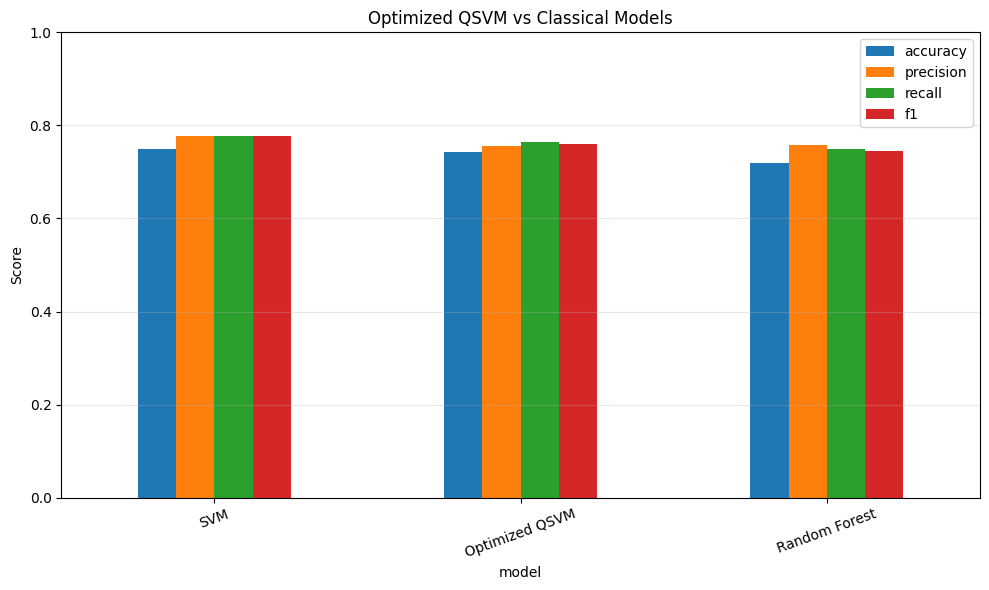

In [53]:
metrics = ["accuracy", "precision", "recall", "f1"]

plot_df = final_results_df.set_index("model")[metrics]

ax = plot_df.plot(kind="bar", figsize=(10, 6))

plt.title("Optimized QSVM vs Classical Models")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(PLOTS_DIR / "optimized_qsvm_vs_classical_metrics.png", dpi=300)
plt.show()

## 25) Training time comparison chart

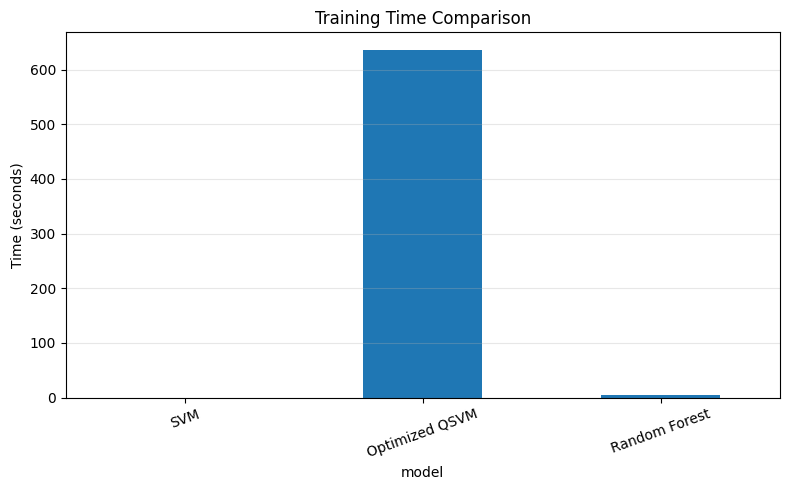

In [54]:
time_df = final_results_df.set_index("model")["time_sec"]

ax = time_df.plot(kind="bar", figsize=(8, 5))

plt.title("Training Time Comparison")
plt.ylabel("Time (seconds)")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(PLOTS_DIR / "optimized_training_time_comparison.png", dpi=300)
plt.show()

## 26) Analyze preprocessing effect

In [55]:
preprocessing_effect = qsvm_results_df.groupby("scaler")[["accuracy", "precision", "recall", "f1", "time_sec"]].mean()
preprocessing_effect = preprocessing_effect.sort_values(by="accuracy", ascending=False)

preprocessing_effect

,accuracy,precision,recall,f1,time_sec
scaler,,,,,
dual_standard_minmax,0.718750,0.746690,0.734954,0.739586,810.579235
robust_minmax,0.718750,0.746690,0.734954,0.739586,688.712160
standard,0.369141,0.406223,0.355035,0.357463,700.038312
minmax,0.367188,0.383842,0.360243,0.364100,755.453140


## 27) Plot preprocessing effect

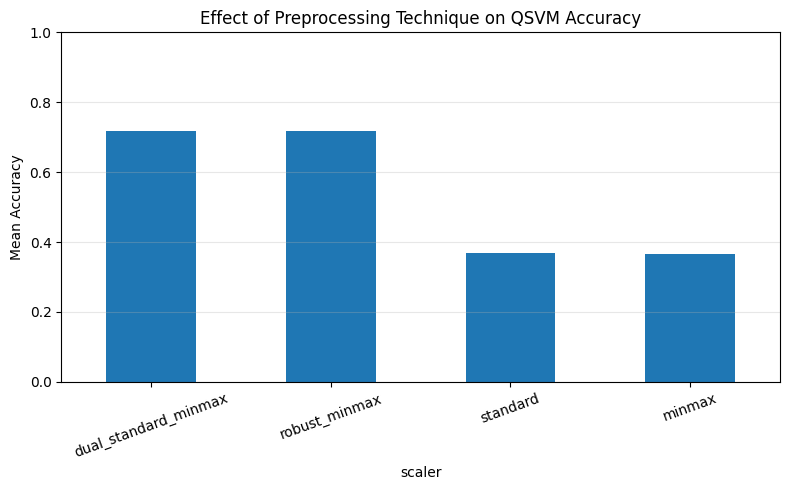

In [56]:
preprocessing_effect["accuracy"].plot(kind="bar", figsize=(8, 5))

plt.title("Effect of Preprocessing Technique on QSVM Accuracy")
plt.ylabel("Mean Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(PLOTS_DIR / "qsvm_preprocessing_effect.png", dpi=300)
plt.show()

## 28) Analyze encoding effect

In [57]:
encoding_effect = qsvm_results_df.groupby("encoding")[["accuracy", "precision", "recall", "f1", "time_sec"]].mean()
encoding_effect = encoding_effect.sort_values(by="accuracy", ascending=False)

encoding_effect

,accuracy,precision,recall,f1,time_sec
encoding,,,,,
pauli_zz,0.518415,0.545743,0.519345,0.523126,719.134454
zz,0.518415,0.545743,0.519345,0.523126,755.128402


## 29) Plot encoding effect

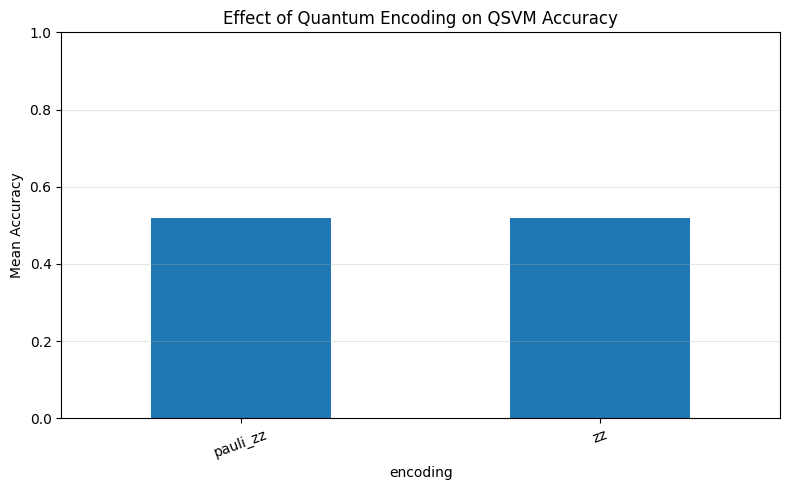

In [58]:
encoding_effect["accuracy"].plot(kind="bar", figsize=(8, 5))

plt.title("Effect of Quantum Encoding on QSVM Accuracy")
plt.ylabel("Mean Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(PLOTS_DIR / "qsvm_encoding_effect.png", dpi=300)
plt.show()

## 30) Analyze entanglement effect

In [59]:
entanglement_effect = qsvm_results_df.groupby("entanglement")[["accuracy", "precision", "recall", "f1", "time_sec"]].mean()
entanglement_effect = entanglement_effect.sort_values(by="accuracy", ascending=False)

entanglement_effect

,accuracy,precision,recall,f1,time_sec
entanglement,,,,,
full,0.687500,0.730007,0.701389,0.713286,795.772372
circular,0.492188,0.523871,0.487269,0.490540,737.765885
linear,0.488281,0.506194,0.490741,0.492325,716.949990


## 31) Plot entanglement effect

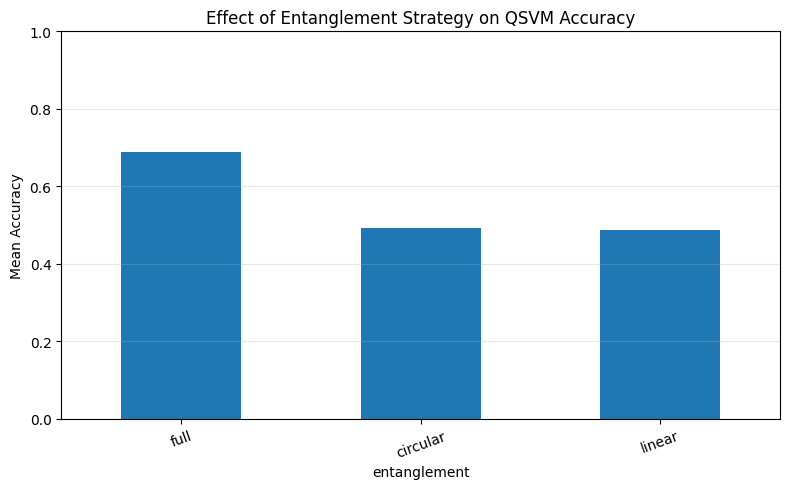

In [60]:
entanglement_effect["accuracy"].plot(kind="bar", figsize=(8, 5))

plt.title("Effect of Entanglement Strategy on QSVM Accuracy")
plt.ylabel("Mean Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(PLOTS_DIR / "qsvm_entanglement_effect.png", dpi=300)
plt.show()

## 32) Analyze circuit depth effect

In [61]:
reps_effect = qsvm_results_df.groupby("reps")[["accuracy", "precision", "recall", "f1", "time_sec"]].mean()
reps_effect = reps_effect.sort_values(by="accuracy", ascending=False)

reps_effect

,accuracy,precision,recall,f1,time_sec
reps,,,,,
1,0.518415,0.545743,0.519345,0.523126,737.131428


## 33) Plot circuit depth effect

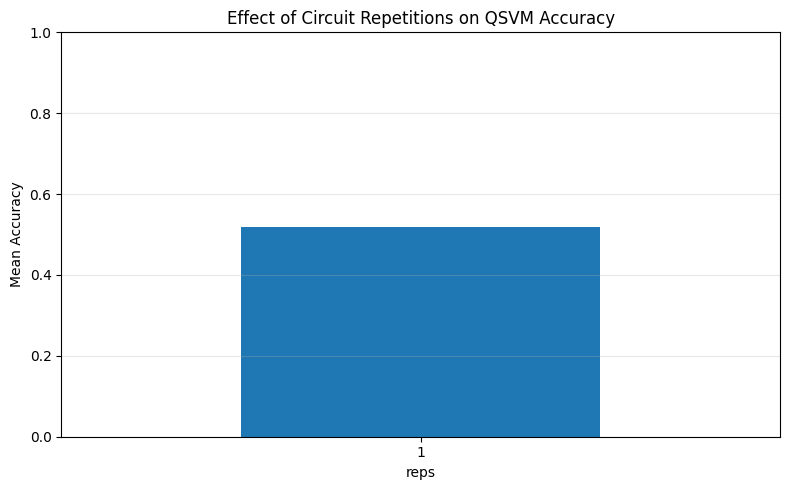

In [62]:
reps_effect["accuracy"].plot(kind="bar", figsize=(8, 5))

plt.title("Effect of Circuit Repetitions on QSVM Accuracy")
plt.ylabel("Mean Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(PLOTS_DIR / "qsvm_reps_effect.png", dpi=300)
plt.show()

## 34) Save file-by-file results

In [63]:
best_qsvm_file_results.to_csv(
    OUTPUT_DIR / "optimized_qsvm_file_by_file_results.csv",
    index=False
)

results_rf_df.to_csv(
    OUTPUT_DIR / "optimized_rf_file_by_file_results.csv",
    index=False
)

results_svm_df.to_csv(
    OUTPUT_DIR / "optimized_svm_file_by_file_results.csv",
    index=False
)

print("Saved file-by-file results.")

Saved file-by-file results.


## 35) Confusion matrices

In [67]:
from sklearn.metrics import confusion_matrix

# Load saved prediction files
qsvm_pred_df = pd.read_csv("../data/processed/best_qsvm_predictions.csv")
rf_pred_df   = pd.read_csv("../data/processed/rf_predictions.csv")
svm_pred_df  = pd.read_csv("../data/processed/svm_predictions.csv")

# Compute confusion matrices
cm_qsvm = confusion_matrix(
    qsvm_pred_df["y_true"],
    qsvm_pred_df["y_pred"]
)

cm_rf = confusion_matrix(
    rf_pred_df["y_true"],
    rf_pred_df["y_pred"]
)

cm_svm = confusion_matrix(
    svm_pred_df["y_true"],
    svm_pred_df["y_pred"]
)

print("QSVM Confusion Matrix:")
print(cm_qsvm)

print("\nRandom Forest Confusion Matrix:")
print(cm_rf)

print("\nSVM Confusion Matrix:")
print(cm_svm)

QSVM Confusion Matrix:
[[30  2  0]
 [ 3 31 14]
 [ 1 13 34]]

Random Forest Confusion Matrix:
[[32  0  0]
 [ 0 37 11]
 [ 0 25 23]]

SVM Confusion Matrix:
[[32  0  0]
 [ 0 32 16]
 [ 0 16 32]]


## 36) Plot confusion matrix function

In [68]:
def plot_confusion_matrix(cm, title, filename):

    plt.figure(figsize=(6, 5))
    plt.imshow(cm)
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(LABEL_NAMES))
    plt.xticks(tick_marks, [LABEL_NAMES[i] for i in sorted(LABEL_NAMES.keys())], rotation=20)
    plt.yticks(tick_marks, [LABEL_NAMES[i] for i in sorted(LABEL_NAMES.keys())])

    plt.xlabel("Predicted")
    plt.ylabel("True")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / filename, dpi=300)
    plt.show()

## 37) Plot confusion matrices

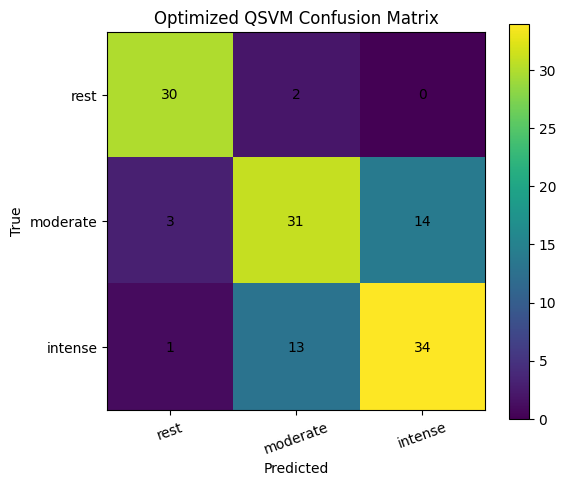

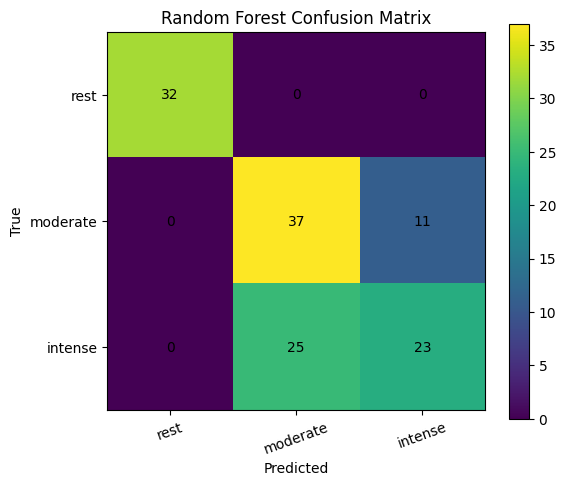

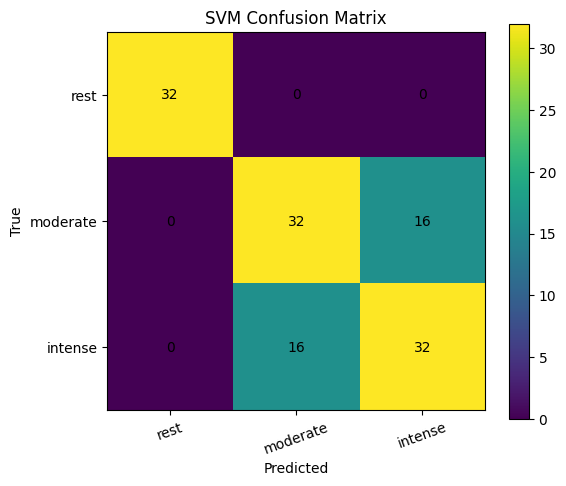

In [69]:
plot_confusion_matrix(
    cm_qsvm,
    "Optimized QSVM Confusion Matrix",
    "optimized_qsvm_confusion_matrix.png"
)

plot_confusion_matrix(
    cm_rf,
    "Random Forest Confusion Matrix",
    "optimized_rf_confusion_matrix.png"
)

plot_confusion_matrix(
    cm_svm,
    "SVM Confusion Matrix",
    "optimized_svm_confusion_matrix.png"
)

## 38) Classification reports

In [70]:
print("Optimized QSVM Report:")
print(classification_report(
    all_true_qsvm,
    all_preds_qsvm,
    target_names=[LABEL_NAMES[i] for i in sorted(LABEL_NAMES.keys())],
    zero_division=0
))

print("\nRandom Forest Report:")
print(classification_report(
    all_true_rf,
    all_preds_rf,
    target_names=[LABEL_NAMES[i] for i in sorted(LABEL_NAMES.keys())],
    zero_division=0
))

print("\nSVM Report:")
print(classification_report(
    all_true_svm,
    all_preds_svm,
    target_names=[LABEL_NAMES[i] for i in sorted(LABEL_NAMES.keys())],
    zero_division=0
))

Optimized QSVM Report:
              precision    recall  f1-score   support

        rest       0.88      0.94      0.91        32
    moderate       0.67      0.65      0.66        48
     intense       0.71      0.71      0.71        48

    accuracy                           0.74       128
   macro avg       0.75      0.76      0.76       128
weighted avg       0.74      0.74      0.74       128


Random Forest Report:
              precision    recall  f1-score   support

        rest       1.00      1.00      1.00        32
    moderate       0.60      0.77      0.67        48
     intense       0.68      0.48      0.56        48

    accuracy                           0.72       128
   macro avg       0.76      0.75      0.74       128
weighted avg       0.73      0.72      0.71       128


SVM Report:
              precision    recall  f1-score   support

        rest       1.00      1.00      1.00        32
    moderate       0.67      0.67      0.67        48
     intense    

## 39) Save summary text for report

In [71]:
summary_text = f"""
QSVM Optimization Summary

This notebook explored preprocessing strategies, feature-reduction choices,
quantum encoding methods, and entanglement topologies for multiclass wearable
activity classification.

Tested preprocessing methods:
- StandardScaler
- MinMaxScaler
- StandardScaler followed by MinMaxScaler
- RobustScaler followed by MinMaxScaler

Tested feature reduction methods:
- PCA with 3 and 4 components
- Manually selected benchmark 4 features

Tested quantum encoding methods:
- ZZFeatureMap
- PauliFeatureMap with Z and ZZ terms

Tested entanglement strategies:
- Linear
- Circular
- Full

Tested circuit repetitions:
- reps = 1

Best QSVM configuration:
Scaler: {best_qsvm['scaler']}
Reducer: {best_qsvm['reducer']}
Encoding: {best_qsvm['encoding']}
Entanglement: {best_qsvm['entanglement']}
Repetitions: {best_qsvm['reps']}

Best QSVM performance:
Accuracy: {best_qsvm['accuracy']:.4f}
Precision: {best_qsvm['precision']:.4f}
Recall: {best_qsvm['recall']:.4f}
F1-score: {best_qsvm['f1']:.4f}
Training time: {best_qsvm['time_sec']:.2f} seconds

Final comparison:
{final_results_df.to_string(index=False)}

Conclusion:
The results show that QSVM performance is highly sensitive to preprocessing
and feature representation. PCA-based configurations performed poorly, while
the alternative benchmark-feature configurations with quantum-friendly scaling
substantially improved QSVM performance. Classical SVM achieved the strongest
overall performance, but the optimized QSVM became highly competitive.
"""

summary_path = LOGS_DIR / "optimized_qsvm_summary.txt"

with open(summary_path, "w", encoding="utf-8") as f:
    f.write(summary_text)

print(summary_text)
print("Saved:", summary_path)


QSVM Optimization Summary

This notebook explored preprocessing strategies, feature-reduction choices,
quantum encoding methods, and entanglement topologies for multiclass wearable
activity classification.

Tested preprocessing methods:
- StandardScaler
- MinMaxScaler
- StandardScaler followed by MinMaxScaler
- RobustScaler followed by MinMaxScaler

Tested feature reduction methods:
- PCA with 3 and 4 components
- Manually selected benchmark 4 features

Tested quantum encoding methods:
- ZZFeatureMap
- PauliFeatureMap with Z and ZZ terms

Tested entanglement strategies:
- Linear
- Circular
- Full

Tested circuit repetitions:
- reps = 1

Best QSVM configuration:
Scaler: robust_minmax
Reducer: benchmark_4
Encoding: pauli_zz
Entanglement: linear
Repetitions: 1

Best QSVM performance:
Accuracy: 0.7422
Precision: 0.7549
Recall: 0.7639
F1-score: 0.7590
Training time: 636.50 seconds

Final comparison:
         model        scaler     reducer  encoding entanglement reps  accuracy  precision  

## CONCLUSION

# Notebook complete.

Generated:
- QSVM optimization results
- Best QSVM configuration
- RF / SVM / QSVM comparison
- Preprocessing effect chart
- Encoding effect chart
- Entanglement effect chart
- Circuit depth effect chart
- Training time chart
- Confusion matrices
- Report-ready summary text
